<a href="https://colab.research.google.com/github/5555yxy/deeplearning/blob/main/docs/labs/lab4/4_4_GPU.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Part 4: Using GPU acceleration with PyTorch

In [2]:
# Execute this code block to install dependencies
try:
    import torchbearer
except:
    !pip install torchbearer

## Manual use of `.cuda()`

Now the magic of PyTorch comes in. So far, we've only been using the CPU to do computation. When we want to scale to a bigger problem, that won't be feasible for very long.
|
PyTorch makes it really easy to use the GPU for accelerating computation. Consider the following code that computes the element-wise product of two large matrices:

In [3]:
import torch

t1 = torch.randn(1000, 1000)
t2 = torch.randn(1000, 1000)
t3 = t1*t2
print(t3)

tensor([[ 8.9182e-01,  3.0668e-02, -1.1263e-01,  ..., -1.0611e+00,
          3.6949e-01,  8.1628e-01],
        [ 7.1407e-01,  1.2095e-01, -8.3372e-01,  ...,  7.0149e-01,
          3.9495e-01,  9.8260e-01],
        [ 1.6408e+00,  2.9116e-01,  3.2933e+00,  ..., -7.1511e-01,
         -1.5694e+00,  6.8279e-04],
        ...,
        [-9.1458e-02, -2.1509e-02,  1.1353e-02,  ...,  8.4682e-01,
         -1.2032e-01, -2.3329e+00],
        [-2.7263e+00, -3.1735e+00,  9.5880e-01,  ...,  2.7112e-01,
         -7.5993e-01,  3.5969e-01],
        [ 5.4705e-01, -6.6151e-04,  3.5043e-01,  ..., -1.6055e+00,
          3.3232e-01,  1.3973e+00]])


By sending all the tensors that we are using to the GPU, all the operations on them will also run on the GPU without having to change anything else. If you're running a non-cuda enabled version of PyTorch the following will throw an error; if you have cuda available the following will create the input matrices, copy them to the GPU and perform the multiplication on the GPU itself:

In [4]:
t1 = torch.randn(1000, 1000).cuda()
t2 = torch.randn(1000, 1000).cuda()
t3 = t1*t2
print(t3)

tensor([[ 0.1748,  0.7955, -2.1637,  ...,  2.0793, -2.0982, -0.0064],
        [ 0.0271,  0.9204,  1.4883,  ..., -1.2144, -0.3353,  0.0850],
        [-0.3714,  0.8028, -0.3249,  ..., -1.3905,  0.1117, -0.6284],
        ...,
        [-0.9279, -0.6987, -0.9450,  ...,  0.9202, -0.5576,  0.2850],
        [-1.6071,  0.1595, -0.1127,  ..., -0.4401, -0.4580, -0.0454],
        [ 1.4612, -0.7693,  1.0741,  ...,  0.1052, -0.3010, -1.2992]],
       device='cuda:0')


If you're running this workbook in colab, now enable GPU acceleration (`Runtime->Runtime Type` and add a `GPU` in the hardware accelerator pull-down). You'll then need to re-run all cells to this point.

If you were able to run the above with hardware acceleration, the print-out of the result tensor would show that it was an instance of `cuda.FloatTensor` type on the the `(GPU 0)` GPU device. If your wanted to copy the tensor back to the CPU, you would use the `.cpu()` method.

## Writing platform agnostic code

Most of the time you'd like to write code that is device agnostic; that is it will run on a GPU if one is available, and otherwise it would fall back to the CPU. The recommended way to do this is as follows:

In [5]:
device = "cuda:0" if torch.cuda.is_available() else "cpu"
t1 = torch.randn(1000, 1000).to(device)
t2 = torch.randn(1000, 1000).to(device)
t3 = t1*t2
print(t3)

tensor([[ 3.4542e-01, -4.4159e-01,  1.7291e+00,  ...,  1.2486e-01,
         -8.1230e-02, -1.2476e+00],
        [ 6.0702e+00, -2.5375e-01,  4.0665e-01,  ...,  4.5854e-01,
          4.0216e+00,  3.0783e-01],
        [ 6.3169e-01, -1.8509e-01, -2.0330e+00,  ...,  2.2263e+00,
          3.4784e-02,  1.3266e+00],
        ...,
        [-3.9318e-01, -7.9480e-02, -2.3681e-01,  ...,  7.8903e-01,
         -1.2455e+00, -1.5074e+00],
        [ 6.5851e-01,  5.4188e-01,  1.9250e-03,  ...,  6.2902e-02,
         -4.1261e-01,  3.5197e+00],
        [-4.6070e+00, -7.5310e-02,  1.7394e-01,  ...,  5.8070e-02,
          4.0587e-01, -2.3495e-01]], device='cuda:0')


## Accelerating neural net training

If you wanted to accelerate the training of a neural net using raw PyTorch, you would have to copy both the model and the training data to the GPU. Unless you were using a really small dataset like MNIST, you would typically _stream_ the batches of training data to the GPU as you used them in the training loop:

```python
device = "cuda:0" if torch.cuda.is_available() else "cpu"
model = BaselineModel(784, 784, 10).to(device)

loss_function = ...
optimiser = ...

for epoch in range(10):
    for data in trainloader:
        inputs, labels = data
        inputs, labels = inputs.to(device), labels.to(device)

        optimiser.zero_grad()
        outputs = model(inputs)
        loss = loss_function(outputs, labels)
        loss.backward()
        optimiser.step()
```

Using Torchbearer, this becomes much simpler - you just tell the `Trial` to run on the GPU and that's it!:

```python
model = BetterCNN()

loss_function = ...
optimiser = ...

device = "cuda:0" if torch.cuda.is_available() else "cpu"
trial = Trial(model, optimiser, loss_function, metrics=['loss', 'accuracy']).to(device)
trial.with_generators(trainloader)
trial.run(epochs=10)
```


## Multiple GPUs

Using multiple GPUs is beyond the scope of the lab, but if you have multiple cuda devices, they can be referred to by index: `cuda:0`, `cuda:1`, `cuda:2`, etc. You have to be careful not to mix operations on different devices, and would need how to carefully orchestrate moving of data between the devices (which can really slow down your code to the point at which using the CPU would actually be faster).

## Questions

__Answer the following questions (enter the answer in the box below each one):__

__1.__ What features of GPUs allow them to perform computations faster than a typically CPU?

YOUR ANSWER HERE

__2.__ What is the biggest limiting factor for training large models with current generation GPUs?

YOUR ANSWER HERE

In [2]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
from torchvision.datasets import MNIST
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# -------------------------
# 1. Device setup
# -------------------------
if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")

print("Using device:", device)

# -------------------------
# 2. Reproducibility
# -------------------------
seed = 7
torch.manual_seed(seed)
np.random.seed(seed)

# -------------------------
# 3. Load MNIST
# -------------------------
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Lambda(lambda x: x.view(-1))
])

trainset = MNIST(".", train=True, download=True, transform=transform)
testset = MNIST(".", train=False, download=True, transform=transform)

trainloader = DataLoader(trainset, batch_size=128, shuffle=True)
testloader = DataLoader(testset, batch_size=128, shuffle=False)

# -------------------------
# 4. Define MLP
# -------------------------
class BaselineModel(nn.Module):
    def __init__(self, hidden_size):
        super().__init__()
        self.fc1 = nn.Linear(784, hidden_size)
        self.fc2 = nn.Linear(hidden_size, 10)

    def forward(self, x):
        x = F.relu(self.fc1(x))
        x = self.fc2(x)
        return x

# -------------------------
# 5. Count parameters
# -------------------------
def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

# -------------------------
# 6. Train one epoch
# -------------------------
def train_one_epoch(model, loader, loss_fn, optimiser, device):
    model.train()

    total_loss = 0.0
    correct = 0
    total = 0

    for data, target in loader:
        data = data.to(device)
        target = target.to(device)

        optimiser.zero_grad()
        logits = model(data)
        loss = loss_fn(logits, target)

        loss.backward()
        optimiser.step()

        total_loss += loss.item() * data.size(0)
        pred = logits.argmax(dim=1)
        correct += (pred == target).sum().item()
        total += data.size(0)

    avg_loss = total_loss / total
    accuracy = correct / total

    return avg_loss, accuracy

# -------------------------
# 7. Evaluate
# -------------------------
def evaluate(model, loader, loss_fn, device):
    model.eval()

    total_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        for data, target in loader:
            data = data.to(device)
            target = target.to(device)

            logits = model(data)
            loss = loss_fn(logits, target)

            total_loss += loss.item() * data.size(0)
            pred = logits.argmax(dim=1)
            correct += (pred == target).sum().item()
            total += data.size(0)

    avg_loss = total_loss / total
    accuracy = correct / total

    return avg_loss, accuracy

# -------------------------
# 8. Run experiments
# -------------------------
hidden_sizes = [64, 128, 256, 512, 1024, 2048, 4096, 8192]
epochs = 10

all_history = {}
summary_rows = []

for hidden_size in hidden_sizes:
    print(f"\nTraining hidden_size = {hidden_size}")

    model = BaselineModel(hidden_size).to(device)
    loss_fn = nn.CrossEntropyLoss()
    optimiser = torch.optim.Adam(model.parameters(), lr=0.001)

    history = {
        "train_loss": [],
        "test_loss": [],
        "train_acc": [],
        "test_acc": []
    }

    for epoch in range(epochs):
        train_loss, train_acc = train_one_epoch(
            model, trainloader, loss_fn, optimiser, device
        )
        test_loss, test_acc = evaluate(
            model, testloader, loss_fn, device
        )

        history["train_loss"].append(train_loss)
        history["test_loss"].append(test_loss)
        history["train_acc"].append(train_acc)
        history["test_acc"].append(test_acc)

        print(
            f"Epoch {epoch+1:02d}: "
            f"train_loss={train_loss:.4f}, train_acc={train_acc:.4f}, "
            f"test_loss={test_loss:.4f}, test_acc={test_acc:.4f}"
        )

    all_history[hidden_size] = history

    summary_rows.append({
        "hidden_size": hidden_size,
        "parameters": count_parameters(model),
        "final_train_loss": history["train_loss"][-1],
        "final_test_loss": history["test_loss"][-1],
        "final_train_acc": history["train_acc"][-1],
        "final_test_acc": history["test_acc"][-1],
        "train_test_acc_gap": history["train_acc"][-1] - history["test_acc"][-1]
    })

summary_df = pd.DataFrame(summary_rows)
print(summary_df)

Using device: cuda


100%|██████████| 9.91M/9.91M [00:00<00:00, 18.1MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 479kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.45MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 3.85MB/s]



Training hidden_size = 64
Epoch 01: train_loss=0.4787, train_acc=0.8733, test_loss=0.2701, test_acc=0.9238
Epoch 02: train_loss=0.2391, train_acc=0.9320, test_loss=0.2031, test_acc=0.9411
Epoch 03: train_loss=0.1860, train_acc=0.9468, test_loss=0.1664, test_acc=0.9516
Epoch 04: train_loss=0.1522, train_acc=0.9564, test_loss=0.1436, test_acc=0.9572
Epoch 05: train_loss=0.1273, train_acc=0.9633, test_loss=0.1277, test_acc=0.9622
Epoch 06: train_loss=0.1092, train_acc=0.9688, test_loss=0.1147, test_acc=0.9675
Epoch 07: train_loss=0.0952, train_acc=0.9725, test_loss=0.1040, test_acc=0.9697
Epoch 08: train_loss=0.0842, train_acc=0.9750, test_loss=0.0963, test_acc=0.9714
Epoch 09: train_loss=0.0743, train_acc=0.9782, test_loss=0.0911, test_acc=0.9730
Epoch 10: train_loss=0.0669, train_acc=0.9802, test_loss=0.0917, test_acc=0.9717

Training hidden_size = 128
Epoch 01: train_loss=0.4141, train_acc=0.8909, test_loss=0.2233, test_acc=0.9362
Epoch 02: train_loss=0.1934, train_acc=0.9448, test_lo

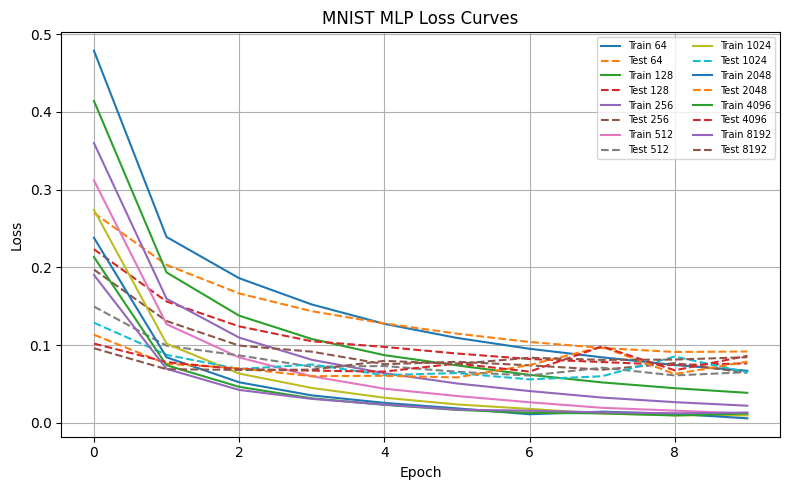

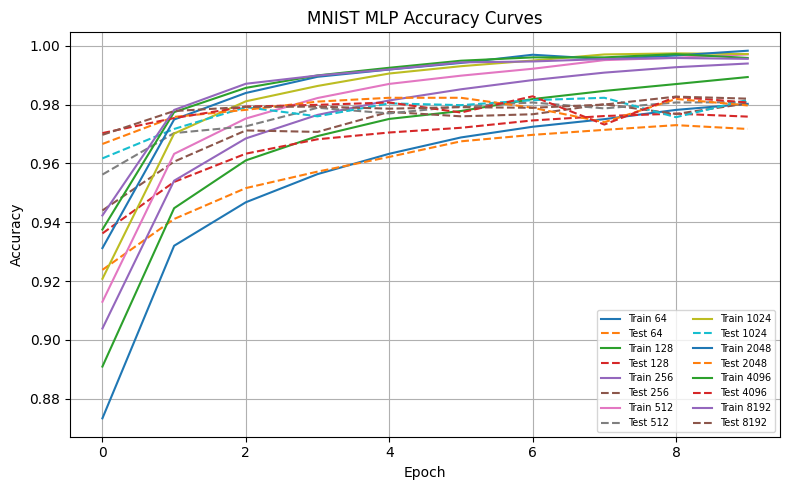

In [3]:
import matplotlib.pyplot as plt

# 1. Plot loss curves
plt.figure(figsize=(8, 5))

for hidden_size, history in all_history.items():
    plt.plot(
        history["train_loss"],
        linestyle="-",
        label=f"Train {hidden_size}"
    )
    plt.plot(
        history["test_loss"],
        linestyle="--",
        label=f"Test {hidden_size}"
    )

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("MNIST MLP Loss Curves")
plt.legend(fontsize=7, ncol=2)
plt.grid(True)
plt.tight_layout()
plt.savefig("mnist_loss_curves.png", dpi=200)
plt.show()


# 2. Plot accuracy curves
plt.figure(figsize=(8, 5))

for hidden_size, history in all_history.items():
    plt.plot(
        history["train_acc"],
        linestyle="-",
        label=f"Train {hidden_size}"
    )
    plt.plot(
        history["test_acc"],
        linestyle="--",
        label=f"Test {hidden_size}"
    )

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("MNIST MLP Accuracy Curves")
plt.legend(fontsize=7, ncol=2)
plt.grid(True)
plt.tight_layout()
plt.savefig("mnist_accuracy_curves.png", dpi=200)
plt.show()